# 03 — Обучение и сравнение моделей растворимости

Вход — результаты `02_split_and_rdkit_features.ipynb`. Основной запуск сравнивает:

1. Физический бейзлайн: \(b=x_1\log S_1+x_2\log S_2\).
2. **LinearRegression, RandomForestRegressor, GradientBoostingRegressor** с целями
   `logS_mix` и `delta_logS`. Для второй цели предсказание восстанавливается как \(b+\widehat\Delta\).
3. **Подход Глеба:** небольшая сеть выдаёт коэффициенты кривой, а loss считается
   непосредственно по растворимости в экспериментальных точках:

\[
\widehat{\log S}(x)=x\log S_1+(1-x)\log S_2+
\sqrt{x(1-x)}\sum_{k=0}^{4}a_k(Q)x^k.
\]

Архитектура `[32, 16]`, SELU, Adam, степень 4 и множитель \(\sqrt{x(1-x)}\)
взяты из `New_way_predict.ipynb`. **Исправлен порядок endpoints**: x=1 соответствует
первому растворителю. Коэффициенты не подгоняются заранее по каждой кривой.
Сеть учится сквозным образом через ошибку конечного прогноза.

Это адаптация идеи Глеба к единому датасету и десяти RDKit-признакам из диплома,
а не побитовое повторение его набора признаков и разбиения. Q содержит T, две чистые
растворимости и дескрипторы растворителей; состав x подаётся только в формулу кривой.
По умолчанию сеть проверяется без аугментации и с перестановкой растворителей,
чтобы эффект аугментации был виден отдельно. Деревья и линейная модель обучаются
без аугментации, как итоговое сравнение диплома.

Все метрики считаются на исходных внутренних точках. Подбор эпохи и выбор конфигурации —
только по объединённой validation. Test не используется до завершения обучения.

## 1. Настройки и зависимости

`RUN_GB=False` полностью отключает градиентный бустинг. `GB_MAX_SECONDS` ограничивает
время одного его запуска: остановка происходит после очередного дерева, поэтому лимит
приблизительный. Полученная укороченная модель сохраняется, а число деревьев записывается.
`RUN_GLEB=False` отключает PyTorch-часть. `RUN_GLEB_SWAP_VARIANT=False` оставляет одну сеть.

У RF прогресс обновляется после блока деревьев; у GB — после каждого дерева;
у сети — после эпохи с validation; предсказание — по пакетам строк. ETA появляется
после первых шагов и является оценкой. LinearRegression использует прямой решатель:
для него доступен индикатор выполнения и прошедшее время, достоверной ETA внутри solve нет.
При early stopping ETA сети относится к максимальному числу эпох.

Ноутбук сохраняет каждую модель сразу после обучения. Полный grid search не выполняется.
Параметры по умолчанию предназначены для первого сравнения; это не повтор прежних чисел
диплома на изменившихся данных. Для LR два target часто дают почти одинаковый результат,
поскольку линейный бейзлайн уже входит в её пространство признаков.

In [1]:
import platform
import numpy
import sklearn
import torch
from rdkit import Chem

print('Архитектура:', platform.machine(), flush=True)
print('PyTorch:', torch.__version__, flush=True)
print('MPS:', torch.backends.mps.is_available(), flush=True)
if torch.backends.mps.is_available():
    x = torch.ones(3, device='mps')
    print('Результат на GPU:', (x * 2).cpu(), flush=True)

Архитектура: arm64
PyTorch: 2.14.1
MPS: True
Результат на GPU: tensor([2., 2., 2.])


In [1]:
# %pip install --upgrade torch

In [2]:
import torch

print("PyTorch:", torch.__version__)
print("GPU через MPS доступен:", torch.backends.mps.is_available())

PyTorch: 2.14.1
GPU через MPS доступен: True


In [3]:
# При необходимости установить и перезапустить kernel:
# %pip install numpy pandas matplotlib scikit-learn tqdm joblib
# Для сети нужен PyTorch. CPU-вариант:
# %pip install torch --index-url https://download.pytorch.org/whl/cpu
# Для GPU используйте установку, соответствующую вашей CUDA, с https://pytorch.org/get-started/locally/

In [7]:
from pathlib import Path
import json, time, math, hashlib, platform, copy
from datetime import datetime, timezone
from concurrent.futures import ThreadPoolExecutor, TimeoutError as FutureTimeout
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from tqdm.auto import tqdm
import sklearn, joblib
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

CFG = {
    "SPLIT_DIR": "ml_ready/splits_v1",
    "OUTPUT_DIR": "training_v1",
    "SEED": 42,
    "RUN_LR": True,
    "RUN_RF": True,
    "RUN_GB": True,                 # False — полностью пропустить GB
    "GB_MAX_SECONDS": 300,          # на одну модель; None — без ограничения
    "RUN_GLEB": True,
    "RUN_GLEB_SWAP_VARIANT": True,  # дополнительно сеть с перестановкой растворителей
    "RUN_PHYSICAL_ONLY": False,    # дополнительно повторить обычные модели без RDKit
    "TARGETS": ["logS_mix", "delta_logS"],
    "RF_TREES": 200, "RF_BLOCK_SIZE": 10, "RF_MAX_DEPTH": 20, "RF_MIN_LEAF": 3,
    "N_JOBS": -1,
    "GB_TREES": 300, "GB_LR": 0.05, "GB_DEPTH": 3, "GB_MIN_LEAF": 2,
    "NN_EPOCHS": 300, "NN_PATIENCE": 30, "NN_MIN_DELTA": 1e-5,
    "NN_BATCH_SIZE": 8192, "NN_LR": 1e-3, "NN_HIDDEN": [32, 16], "NN_DEGREE": 4,
    "NN_CPU_THREADS": 4, "NN_DEVICE": "mps",  # auto: CUDA, затем CPU
    "PREDICT_BATCH_SIZE": 4096,
    "EVALUATE_TRAIN": False,
    "EVALUATE_TEST": True,          # для первичного подбора можно поставить False
    "CHECK_SYMMETRY": True,
    "SYMMETRY_ROWS": 1000,
}
SPLIT_NAMES = ["train", "val_unseen_solvent_set", "val_unseen_solute",
               "test_unseen_solvent_set", "test_unseen_solute"]
RDKIT_NAMES = ["BalabanJ", "fr_NH0", "FpDensityMorgan3", "EState_VSA3", "MolLogP"]
RDKIT_FEATURES = [f"solv{side}_{name}" for name in RDKIT_NAMES for side in [1, 2]]
PHYSICAL = ["x1", "x2", "Temperature_bin_K", "logS1", "logS2", "logS_base", "x1_x2",
            "x1_minus_x2", "abs_x1_minus_x2", "logS1_minus_logS2", "abs_logS1_minus_logS2",
            "jouyban_0", "jouyban_1", "jouyban_2", "jouyban_3"]
Q_FEATURES = ["Temperature_bin_K", "logS1", "logS2"] + RDKIT_FEATURES
OUT = Path(CFG["OUTPUT_DIR"])
for folder in ["models", "metrics", "predictions", "figures", "history"]:
    (OUT / folder).mkdir(parents=True, exist_ok=True)
np.random.seed(CFG["SEED"])
if CFG["RUN_GLEB"]:
    try:
        import torch
        from torch import nn
        from torch.utils.data import TensorDataset, DataLoader
    except ImportError as error:
        raise ImportError("Установите torch либо задайте RUN_GLEB=False") from error
    torch.set_num_threads(CFG["NN_CPU_THREADS"])
    DEVICE = ("cuda" if torch.cuda.is_available() else "cpu") if CFG["NN_DEVICE"] == "auto" else CFG["NN_DEVICE"]
    print("Устройство сети:", DEVICE)
display(pd.Series(CFG, name="value").to_frame())

Устройство сети: mps


,value
SPLIT_DIR,ml_ready/splits_v1
OUTPUT_DIR,training_v1
SEED,42
RUN_LR,True
RUN_RF,True
RUN_GB,True
GB_MAX_SECONDS,300
RUN_GLEB,True
RUN_GLEB_SWAP_VARIANT,True
RUN_PHYSICAL_ONLY,False


## 2. Загрузка и защита разбиений

Входные файлы не пересоздаются. Проверяются непересечение веществ/кривых/систем,
отсутствие растворителей A в train и отсутствие endpoints в оцениваемых данных.
Признаки выбираются явным списком, а не как «все числовые колонки».

In [8]:
def physical_features(frame):
    f = frame.copy()
    f["logS_base"] = f.x1*f.logS1 + f.x2*f.logS2
    if "logS_mix" in f: f["delta_logS"] = f.logS_mix-f.logS_base
    f["x1_x2"] = f.x1*f.x2
    f["x1_minus_x2"] = f.x1-f.x2
    f["abs_x1_minus_x2"] = f.x1_minus_x2.abs()
    f["logS1_minus_logS2"] = f.logS1-f.logS2
    f["abs_logS1_minus_logS2"] = f.logS1_minus_logS2.abs()
    for k in range(4): f[f"jouyban_{k}"] = f.x1_x2/f.Temperature_bin_K*f.x1_minus_x2**k
    return f

def swap_solvents(frame):
    f = frame.copy()
    pairs = [("x1", "x2"), ("logS1", "logS2"), ("canon_SMILES_Solvent1", "canon_SMILES_Solvent2")]
    pairs += [(f"solv1_{d}", f"solv2_{d}") for d in RDKIT_NAMES]
    for a, b in pairs:
        if a in f and b in f: f[[a, b]] = frame[[b, a]].to_numpy()
    return physical_features(f)

split_dir = Path(CFG["SPLIT_DIR"])
frames, input_paths = {}, []
for name in tqdm(SPLIT_NAMES, desc="Загрузка выборок", unit="file"):
    path = split_dir / "splits" / f"{name}.csv"
    if not path.is_file(): raise FileNotFoundError(path)
    f = pd.read_csv(path, low_memory=False)
    required = ["experiment_id", "system_group_id", "canon_SMILES_Solute", "canon_SMILES_Solvent1",
                "canon_SMILES_Solvent2", "x1", "x2", "Temperature_bin_K", "logS_mix", "logS1", "logS2"] + RDKIT_FEATURES
    missing = sorted(set(required)-set(f))
    if missing: raise ValueError(f"{name}: отсутствуют {missing}; запустите 02 с ADD_RDKIT=True")
    if f.empty or not f.x1.between(0, 1, inclusive="neither").all():
        raise ValueError(f"{name}: пустая выборка или есть endpoints")
    if "split" in f and not f["split"].eq(name).all(): raise ValueError(f"Неверные метки split в {path}")
    if not np.isfinite(f[["x1", "x2", "Temperature_bin_K", "logS_mix", "logS1", "logS2"]]).all().all():
        raise ValueError(f"{name}: неверные обязательные числа")
    if not f.Temperature_bin_K.gt(0).all() or not np.allclose(f.x1+f.x2, 1., atol=1e-8, rtol=0):
        raise ValueError(f"{name}: неверная T или сумма долей")
    f["split"] = name
    frames[name] = physical_features(f)
    input_paths.append(path)
for i, a in enumerate(SPLIT_NAMES):
    for b in SPLIT_NAMES[i+1:]:
        for key in ["experiment_id", "system_group_id", "canon_SMILES_Solute"]:
            if set(frames[a][key]) & set(frames[b][key]): raise ValueError(f"Пересечение {a}/{b}: {key}")
def solvent_set(f): return set(f.canon_SMILES_Solvent1) | set(f.canon_SMILES_Solvent2)
for name in ["val_unseen_solvent_set", "test_unseen_solvent_set"]:
    if solvent_set(frames[name]) & solvent_set(frames["train"]): raise ValueError(f"Известные растворители в {name}")
train = frames["train"]
validation = pd.concat([frames["val_unseen_solvent_set"], frames["val_unseen_solute"]], ignore_index=True)
FEATURE_SETS = {"physical_plus_rdkit": PHYSICAL + RDKIT_FEATURES}
if CFG["RUN_PHYSICAL_ONLY"]: FEATURE_SETS["physical"] = PHYSICAL
display(pd.DataFrame({k: {"rows": len(v), "curves": v.experiment_id.nunique()} for k,v in frames.items()}).T)

Загрузка выборок:   0%|          | 0/5 [00:00<?, ?file/s]

,rows,curves
train,62436,7963
val_unseen_solvent_set,1004,128
val_unseen_solute,9954,1279
test_unseen_solvent_set,893,130
test_unseen_solute,10536,1277


## 3. Преобразования, метрики и сохранение моделей

Медианы пропусков и параметры StandardScaler определяются только на train.
Для полностью пустого train-признака сохраняется нулевой столбец; об этом выводится сообщение.
Основные метрики: RMSE, MAE и R² в logS, доля ошибок ≤0.3, MedARE в процентах.
Дополнительно — средний RMSE по кривым с одинаковым весом каждой кривой.
Обычные RMSE/MAE дают одинаковый вес каждой точке, как в дипломе.

In [9]:
def make_preprocessor(frame, features, scale):
    X = frame[features].replace([np.inf, -np.inf], np.nan)
    empty = X.columns[X.isna().all()].tolist()
    if empty: print("Полностью пустые train-признаки будут заполнены нулём:", empty)
    steps = [("imputer", SimpleImputer(strategy="median", keep_empty_features=True))]
    if scale: steps.append(("scaler", StandardScaler()))
    prep = Pipeline(steps)
    return prep, np.asarray(prep.fit_transform(X), dtype=np.float64)

def target_values(frame, target):
    if target not in {"logS_mix", "delta_logS"}: raise ValueError(target)
    return frame[target].to_numpy(dtype=float)

def metrics(frame, pred):
    y = frame.logS_mix.to_numpy(dtype=float)
    p = np.asarray(pred, dtype=float)
    if p.shape != y.shape or not np.isfinite(p).all():
        raise ValueError("Прогноз содержит NaN/inf или имеет неверную форму; строки не удаляются молча")
    error = p-y
    with np.errstate(over="ignore"):
        relative = np.abs(np.power(10., error)-1.)
    by_curve = pd.DataFrame({"curve": frame.experiment_id.to_numpy(), "sq_error": error**2}).groupby("curve").sq_error.mean()
    return {"n_points": len(y), "n_curves": len(by_curve),
            "RMSE_logS": float(np.sqrt(mean_squared_error(y,p))),
            "MAE_logS": float(mean_absolute_error(y,p)), "R2_logS": float(r2_score(y,p)),
            "within_0.3": float(np.mean(np.abs(error)<=.3)),
            "MedARE_percent": float(100*np.median(relative)),
            "macro_curve_RMSE": float(np.sqrt(by_curve).mean())}

def save_bundle(bundle):
    folder = OUT/"models"/bundle["id"]
    folder.mkdir(exist_ok=True)
    meta = {k:v for k,v in bundle.items() if k not in ["model", "preprocessor", "history"]}
    (folder/"metadata.json").write_text(json.dumps(meta, ensure_ascii=False, indent=2), encoding="utf-8")
    if bundle["kind"] == "tabular":
        joblib.dump({"model":bundle["model"], "preprocessor":bundle["preprocessor"]}, folder/"model.joblib")
    elif bundle["kind"] == "gleb":
        torch.save({k:v.detach().cpu() for k,v in bundle["model"].state_dict().items()}, folder/"weights.pt")
        joblib.dump(bundle["preprocessor"], folder/"preprocessor.joblib")
        bundle["history"].to_csv(OUT/"history"/f"{bundle['id']}.csv", index=False)

TRAINED = {"physical_baseline": {"id":"physical_baseline", "kind":"baseline", "family":"baseline",
              "target":"none", "feature_set":"physical", "features":[], "train_seconds":0.}}
save_bundle(TRAINED["physical_baseline"])

## 4. Линейная регрессия, случайный лес, градиентный бустинг

RF использует warm_start исключительно для отображения прогресса: новые блоки деревьев
добавляются к той же модели с фиксированным random_state. GB использует callback monitor
для прогресса и временного лимита; test в callback не передаётся.

In [10]:
def fit_linear_progress(model, X, y):
    with ThreadPoolExecutor(max_workers=1) as pool, tqdm(total=1, desc="LinearRegression: solve (ETA недоступна)", unit="fit") as bar:
        future = pool.submit(model.fit, X, y)
        while True:
            try:
                result = future.result(timeout=.3)
                bar.update(1)
                return result
            except FutureTimeout:
                bar.refresh()

def fit_tabular(family, frame, features, target):
    start = time.perf_counter()
    prep, X = make_preprocessor(frame, features, scale=(family=="LinearRegression"))
    y = target_values(frame, target)
    stopped = False
    if family == "LinearRegression":
        model = fit_linear_progress(LinearRegression(), X, y)
    elif family == "RandomForest":
        model = RandomForestRegressor(n_estimators=1, warm_start=True, random_state=CFG["SEED"],
                  max_depth=CFG["RF_MAX_DEPTH"], min_samples_leaf=CFG["RF_MIN_LEAF"], n_jobs=CFG["N_JOBS"])
        previous = 0
        with tqdm(total=CFG["RF_TREES"], desc=f"RF / {target}", unit="tree") as bar:
            while previous < CFG["RF_TREES"]:
                count = min(previous+CFG["RF_BLOCK_SIZE"], CFG["RF_TREES"])
                model.set_params(n_estimators=count)
                model.fit(X,y)
                bar.update(count-previous)
                previous = count
    elif family == "GradientBoosting":
        model = GradientBoostingRegressor(n_estimators=CFG["GB_TREES"], learning_rate=CFG["GB_LR"],
                   max_depth=CFG["GB_DEPTH"], min_samples_leaf=CFG["GB_MIN_LEAF"], random_state=CFG["SEED"])
        with tqdm(total=CFG["GB_TREES"], desc=f"GB / {target}", unit="tree") as bar:
            fit_start = time.perf_counter()
            def monitor(i, estimator, local_vars):
                nonlocal stopped
                bar.update(1)
                limit = CFG["GB_MAX_SECONDS"]
                stopped = limit is not None and time.perf_counter()-fit_start >= limit
                if stopped: bar.set_postfix_str("time limit")
                return stopped
            model.fit(X,y,monitor=monitor)
    else: raise ValueError(family)
    return {"kind":"tabular", "family":family, "target":target, "features":list(features),
            "model":model, "preprocessor":prep, "train_seconds":time.perf_counter()-start,
            "time_limit_reached":stopped,
            "actual_trees":len(model.estimators_) if hasattr(model,"estimators_") else None,
            "parameters":model.get_params()}

families = [name for flag,name in [("RUN_LR","LinearRegression"),("RUN_RF","RandomForest"),("RUN_GB","GradientBoosting")] if CFG[flag]]
jobs = [(family, feature_set, features, target) for feature_set,features in FEATURE_SETS.items()
        for family in families for target in CFG["TARGETS"]]
for family, feature_set, features, target in tqdm(jobs, desc="Обычные модели", unit="model"):
    model_id = f"{family}__{feature_set}__{target}"
    bundle = fit_tabular(family, train, features, target)
    bundle.update(id=model_id, feature_set=feature_set)
    TRAINED[model_id] = bundle
    save_bundle(bundle)
    print(f"{model_id}: {bundle['train_seconds']:.1f} с; деревьев {bundle['actual_trees']}")

Обычные модели:   0%|          | 0/6 [00:00<?, ?model/s]

LinearRegression: solve (ETA недоступна):   0%|          | 0/1 [00:00<?, ?fit/s]

LinearRegression__physical_plus_rdkit__logS_mix: 0.1 с; деревьев None


LinearRegression: solve (ETA недоступна):   0%|          | 0/1 [00:00<?, ?fit/s]

LinearRegression__physical_plus_rdkit__delta_logS: 0.1 с; деревьев None


...

RandomForest__physical_plus_rdkit__delta_logS: 9.5 с; деревьев 200


GB / logS_mix:   0%|          | 0/300 [00:00<?, ?tree/s]

GradientBoosting__physical_plus_rdkit__logS_mix: 39.4 с; деревьев 300


GB / delta_logS:   0%|          | 0/300 [00:00<?, ?tree/s]

GradientBoosting__physical_plus_rdkit__delta_logS: 39.2 с; деревьев 300


## 5. Сеть Глеба: коэффициенты кривой через point-wise loss

Оптимизируется MSE(logS). Состояние с наименьшей validation MSE сохраняется отдельно;
patience отсчитывается от значимого улучшения `NN_MIN_DELTA`. Validation не аугментируется.
Данные test в обучение не передаются. Пакетный loss взвешивается числом точек при усреднении.
Сравниваются сеть без аугментации и, опционально, сеть с удвоенным train перестановкой растворителей.
Аугментация не гарантирует точной симметрии модели — её ошибка проверяется далее.

In [11]:
if CFG["RUN_GLEB"]:
    class PolyCoeffNet(nn.Module):
        def __init__(self, input_dim, degree, hidden):
            super().__init__()
            layers, previous = [], input_dim
            for width in hidden:
                layers += [nn.Linear(previous,width), nn.SELU()]
                previous = width
            layers.append(nn.Linear(previous,degree+1))
            self.net = nn.Sequential(*layers)
        def forward(self,Q): return self.net(Q)

    def curve_value(coeffs, x, logS1, logS2):
        powers = x[:,None]**torch.arange(coeffs.shape[1],device=x.device)[None,:]
        correction = torch.sqrt(torch.clamp(x*(1-x), min=0))*(coeffs*powers).sum(dim=1)
        return x*logS1+(1-x)*logS2+correction

    # Граничные значения должны выполняться при любых коэффициентах.
    probe = curve_value(torch.ones(2,5), torch.tensor([0.,1.]), torch.tensor([-2.,-2.]), torch.tensor([-4.,-4.]))
    assert torch.allclose(probe, torch.tensor([-4.,-2.]))

    def tensor_data(frame, prep, features):
        X = prep.transform(frame[features].replace([np.inf,-np.inf],np.nan)).astype(np.float32)
        arrays = [X] + [frame[c].to_numpy(dtype=np.float32) for c in ["x1","logS1","logS2","logS_mix"]]
        return TensorDataset(*[torch.from_numpy(a) for a in arrays])

    def validation_mse(model, loader):
        model.eval()
        total, count = 0., 0
        with torch.no_grad():
            for Q,x,l1,l2,y in loader:
                Q,x,l1,l2,y = [t.to(DEVICE) for t in [Q,x,l1,l2,y]]
                prediction = curve_value(model(Q),x,l1,l2)
                total += float(((prediction-y)**2).sum().item()); count += len(y)
        return total/count

    def fit_gleb(frame, val, augmented):
        start = time.perf_counter()
        torch.manual_seed(CFG["SEED"])
        if torch.cuda.is_available(): torch.cuda.manual_seed_all(CFG["SEED"])
        training = pd.concat([frame,swap_solvents(frame)],ignore_index=True) if augmented else frame.copy()
        prep, _ = make_preprocessor(training,Q_FEATURES,scale=True)
        generator = torch.Generator().manual_seed(CFG["SEED"])
        train_loader = DataLoader(tensor_data(training,prep,Q_FEATURES),batch_size=CFG["NN_BATCH_SIZE"],shuffle=True,generator=generator)
        val_loader = DataLoader(tensor_data(val,prep,Q_FEATURES),batch_size=CFG["PREDICT_BATCH_SIZE"])
        model = PolyCoeffNet(len(Q_FEATURES),CFG["NN_DEGREE"],CFG["NN_HIDDEN"]).to(DEVICE)
        optimizer = torch.optim.Adam(model.parameters(),lr=CFG["NN_LR"])
        best, patience_reference, stale, best_epoch, best_state = math.inf, math.inf, 0, 0, None
        history = []
        with tqdm(total=CFG["NN_EPOCHS"],desc=f"Gleb NN / swap={augmented}",unit="epoch") as bar:
            for epoch in range(1,CFG["NN_EPOCHS"]+1):
                model.train(); total, count = 0., 0
                for Q,x,l1,l2,y in train_loader:
                    Q,x,l1,l2,y = [t.to(DEVICE) for t in [Q,x,l1,l2,y]]
                    optimizer.zero_grad()
                    prediction = curve_value(model(Q),x,l1,l2)
                    loss = ((prediction-y)**2).mean()
                    if not torch.isfinite(loss): raise FloatingPointError("Нечисловой loss сети")
                    loss.backward(); optimizer.step()
                    total += float(loss.item())*len(y); count += len(y)
                val_mse = validation_mse(model,val_loader)
                if not np.isfinite(val_mse): raise FloatingPointError("Нечисловой validation loss")
                if val_mse < best:
                    best, best_epoch = val_mse, epoch
                    best_state = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
                if val_mse < patience_reference-CFG["NN_MIN_DELTA"]:
                    patience_reference, stale = val_mse, 0
                else: stale += 1
                history.append({"epoch":epoch,"train_MSE":total/count,"val_MSE":val_mse,
                                "train_RMSE":math.sqrt(total/count),"val_RMSE":math.sqrt(val_mse)})
                bar.update(1); bar.set_postfix(train_RMSE=f"{math.sqrt(total/count):.4f}",val_RMSE=f"{math.sqrt(val_mse):.4f}",patience=f"{stale}/{CFG['NN_PATIENCE']}")
                if stale >= CFG["NN_PATIENCE"]:
                    print("Early stopping; лучшая эпоха:",best_epoch)
                    break
        if best_state is None: raise RuntimeError("Сеть не обучена: проверьте число эпох")
        model.load_state_dict(best_state); model.eval()
        return {"kind":"gleb","family":"GlebCoeffNet", "target":"end_to_end_logS",
                "features":Q_FEATURES, "feature_set":"Q_physical_plus_rdkit", "model":model,
                "preprocessor":prep,"history":pd.DataFrame(history),"train_seconds":time.perf_counter()-start,
                "augmented_train":augmented,"training_rows":len(training),"best_epoch":best_epoch,
                "degree":CFG["NN_DEGREE"],"hidden":CFG["NN_HIDDEN"],"best_val_MSE":best,
                "epochs_completed":len(history),"device":DEVICE}

    variants = [False,True] if CFG["RUN_GLEB_SWAP_VARIANT"] else [False]
    for augmented in variants:
        bundle = fit_gleb(train,validation,augmented)
        bundle["id"] = "GlebCoeffNet_swap" if augmented else "GlebCoeffNet"
        TRAINED[bundle["id"]] = bundle
        save_bundle(bundle)

Gleb NN / swap=False:   0%|          | 0/300 [00:00<?, ?epoch/s]

Early stopping; лучшая эпоха: 85


Gleb NN / swap=True:   0%|          | 0/300 [00:00<?, ?epoch/s]

Early stopping; лучшая эпоха: 68


## 6. Единое предсказание с прогрессом и выбор по validation

Все модели возвращают logS независимо от обучающего target. При прогнозе нового
вещества должны быть известны растворимости в двух чистых растворителях.
Предсказания за пределами физического диапазона автоматически не обрезаются:
ошибки модели должны быть видны в метриках.

In [12]:
def predict_logS(bundle, frame, progress=True):
    predictions = []
    batch = CFG["PREDICT_BATCH_SIZE"]
    iterator = range(0,len(frame),batch)
    for start in tqdm(iterator,total=math.ceil(len(frame)/batch),desc=f"Predict {bundle['id']}",unit="batch",disable=not progress,leave=False):
        f = frame.iloc[start:start+batch]
        baseline = (f.x1*f.logS1+f.x2*f.logS2).to_numpy(dtype=float)
        if bundle["kind"] == "baseline": p = baseline
        else:
            dtype = np.float64 if bundle["family"] == "LinearRegression" else np.float32
            X = bundle["preprocessor"].transform(f[bundle["features"]].replace([np.inf,-np.inf],np.nan)).astype(dtype)
            if bundle["kind"] == "tabular":
                p = bundle["model"].predict(X)
                if bundle["target"] == "delta_logS": p = p+baseline
            else:
                model = bundle["model"]; model.eval()
                device = next(model.parameters()).device
                with torch.no_grad():
                    Q = torch.from_numpy(X).to(device)
                    x,l1,l2 = [torch.tensor(f[c].to_numpy(dtype=np.float32),device=device) for c in ["x1","logS1","logS2"]]
                    p = curve_value(model(Q),x,l1,l2).detach().cpu().numpy()
        predictions.append(np.asarray(p,dtype=float))
    return np.concatenate(predictions) if predictions else np.array([],dtype=float)

metric_rows, pred_cache = [], {}
def evaluate_split(split_name, frame):
    for model_id,bundle in tqdm(TRAINED.items(),desc=f"Оценка {split_name}",unit="model"):
        start = time.perf_counter()
        pred = predict_logS(bundle,frame)
        seconds = time.perf_counter()-start
        scores = metrics(frame,pred)
        metric_rows.append({"model_id":model_id,"family":bundle["family"],"target":bundle["target"],
                            "feature_set":bundle["feature_set"],"split":split_name,
                            "train_seconds":bundle["train_seconds"],"predict_seconds":seconds,**scores})
        pred_cache[(model_id,split_name)] = pred
        cols = [c for c in ["measurement_id","experiment_id","system_group_id","split","x1","logS_mix","logS_base"] if c in frame]
        table = frame[cols].copy()
        table["pred_logS"] = pred; table["error_logS"] = pred-frame.logS_mix.to_numpy()
        table.to_csv(OUT/"predictions"/f"{model_id}__{split_name}.csv",index=False)

for name in ["val_unseen_solvent_set","val_unseen_solute"]:
    evaluate_split(name,frames[name])
for model_id,bundle in TRAINED.items():
    pooled = np.concatenate([pred_cache[(model_id,"val_unseen_solvent_set")],pred_cache[(model_id,"val_unseen_solute")]])
    metric_rows.append({"model_id":model_id,"family":bundle["family"],"target":bundle["target"],
                       "feature_set":bundle["feature_set"],"split":"val_combined",
                       "train_seconds":bundle["train_seconds"],"predict_seconds":np.nan,**metrics(validation,pooled)})
validation_ranking = pd.DataFrame(metric_rows).query("split == 'val_combined'").sort_values(["RMSE_logS","model_id"]).reset_index(drop=True)
selected_by_family = validation_ranking.groupby("family",sort=False).head(1).copy()
winner_id = validation_ranking.iloc[0]["model_id"]
selection = {"criterion":"point-weighted RMSE_logS on combined validation",
             "winner_id":winner_id,"selected_by_family":selected_by_family[["family","model_id"]].to_dict(orient="records")}
(OUT/"selection_by_validation.json").write_text(json.dumps(selection,ensure_ascii=False,indent=2),encoding="utf-8")
validation_ranking.to_csv(OUT/"metrics/validation_ranking.csv",index=False)
display(validation_ranking[["model_id","RMSE_logS","MAE_logS","R2_logS","within_0.3","MedARE_percent","macro_curve_RMSE","train_seconds"]])
print("Модель зафиксирована по validation:",winner_id)

Оценка val_unseen_solvent_set:   0%|          | 0/9 [00:00<?, ?model/s]

Predict physical_baseline:   0%|          | 0/1 [00:00<?, ?batch/s]

Predict LinearRegression__physical_plus_rdkit__logS_mix:   0%|          | 0/1 [00:00<?, ?batch/s]

Predict LinearRegression__physical_plus_rdkit__delta_logS:   0%|          | 0/1 [00:00<?, ?batch/s]

Predict RandomForest__physical_plus_rdkit__logS_mix:   0%|          | 0/1 [00:00<?, ?batch/s]

...

Predict GradientBoosting__physical_plus_rdkit__delta_logS:   0%|          | 0/3 [00:00<?, ?batch/s]

Predict GlebCoeffNet:   0%|          | 0/3 [00:00<?, ?batch/s]

Predict GlebCoeffNet_swap:   0%|          | 0/3 [00:00<?, ?batch/s]

,model_id,RMSE_logS,MAE_logS,R2_logS,within_0.3,MedARE_percent,macro_curve_RMSE,train_seconds
0,GradientBoosting__physical_plus_rdkit__delta_logS,0.278144,0.195263,0.938781,0.789378,31.075682,0.209920,39.222773
1,GlebCoeffNet,0.283088,0.200696,0.936585,0.785362,31.492448,0.219154,69.399840
2,GradientBoosting__physical_plus_rdkit__logS_mix,0.284703,0.197559,0.935859,0.795036,30.605795,0.212355,39.431776
3,LinearRegression__physical_plus_rdkit__logS_mix,0.291534,0.211721,0.932744,0.770031,35.467661,0.234574,0.130012
4,LinearRegression__physical_plus_rdkit__delta_logS,0.291534,0.211721,0.932744,0.770031,35.467661,0.234574,0.090299
5,GlebCoeffNet_swap,0.293351,0.207904,0.931903,0.771309,32.084634,0.222258,110.853578
6,RandomForest__physical_plus_rdkit__logS_mix,0.297520,0.197019,0.929954,0.787187,27.652302,0.215818,9.168195
7,RandomForest__physical_plus_rdkit__delta_logS,0.332184,0.212272,0.912681,0.775506,28.477024,0.227118,9.484552
8,physical_baseline,0.567747,0.377996,0.744929,0.555393,45.024867,0.394429,0.000000


Модель зафиксирована по validation: GradientBoosting__physical_plus_rdkit__delta_logS


## 7. Окончательная оценка test A/B

Показываются все заранее заявленные варианты и отдельно варианты, выбранные по validation.
Не переопределяйте победителя по этой таблице. Если после просмотра test меняете модель,
считайте такую оценку исследовательской; для независимого вывода понадобится новый holdout.

In [13]:
if CFG["EVALUATE_TEST"]:
    for name in ["test_unseen_solvent_set","test_unseen_solute"]:
        evaluate_split(name,frames[name])
if CFG["EVALUATE_TRAIN"]:
    evaluate_split("train",train)
all_metrics = pd.DataFrame(metric_rows)
all_metrics.to_csv(OUT/"metrics/all_metrics.csv",index=False)
if CFG["EVALUATE_TEST"]:
    test_metrics = all_metrics.loc[all_metrics.split.str.startswith("test_")].copy()
    test_metrics.to_csv(OUT/"metrics/test_all_predeclared.csv",index=False)
    selected_test = test_metrics.loc[test_metrics.model_id.isin(set(selected_by_family.model_id))].copy()
    selected_test["overall_validation_winner"] = selected_test.model_id.eq(winner_id)
    selected_test.to_csv(OUT/"metrics/test_selected_by_validation.csv",index=False)
    print("Конфигурации каждого семейства, выбранные по validation:")
    display(selected_test[["model_id","split","RMSE_logS","MAE_logS","R2_logS","within_0.3","MedARE_percent","overall_validation_winner"]])
    print("Все заранее заявленные модели, RMSE:")
    display(test_metrics.pivot(index="model_id",columns="split",values="RMSE_logS"))

Оценка test_unseen_solvent_set:   0%|          | 0/9 [00:00<?, ?model/s]

Predict physical_baseline:   0%|          | 0/1 [00:00<?, ?batch/s]

Predict LinearRegression__physical_plus_rdkit__logS_mix:   0%|          | 0/1 [00:00<?, ?batch/s]

Predict LinearRegression__physical_plus_rdkit__delta_logS:   0%|          | 0/1 [00:00<?, ?batch/s]

Predict RandomForest__physical_plus_rdkit__logS_mix:   0%|          | 0/1 [00:00<?, ?batch/s]

...

Predict GlebCoeffNet_swap:   0%|          | 0/3 [00:00<?, ?batch/s]

Конфигурации каждого семейства, выбранные по validation:


,model_id,split,RMSE_logS,MAE_logS,R2_logS,within_0.3,MedARE_percent,overall_validation_winner
27,physical_baseline,test_unseen_solvent_set,0.341822,0.225082,0.876548,0.724524,22.822942,False
28,LinearRegression__physical_plus_rdkit__logS_mix,test_unseen_solvent_set,0.275431,0.217414,0.919847,0.741321,42.288273,False
30,RandomForest__physical_plus_rdkit__logS_mix,test_unseen_solvent_set,0.287051,0.221960,0.912941,0.725644,39.726218,False
33,GradientBoosting__physical_plus_rdkit__delta_logS,test_unseen_solvent_set,0.255809,0.194571,0.930860,0.782755,35.840265,True
34,GlebCoeffNet,test_unseen_solvent_set,0.361135,0.295503,0.862204,0.557671,59.659275,False
36,physical_baseline,test_unseen_solute,0.721216,0.513462,0.583191,0.464882,55.134897,False
37,LinearRegression__physical_plus_rdkit__logS_mix,test_unseen_solute,0.316085,0.230450,0.919940,0.746773,38.299421,False
39,RandomForest__physical_plus_rdkit__logS_mix,test_unseen_solute,0.305234,0.209828,0.925343,0.768413,32.335566,False
42,GradientBoosting__physical_plus_rdkit__delta_logS,test_unseen_solute,0.287156,0.202953,0.933924,0.789104,33.423804,True
43,GlebCoeffNet,test_unseen_solute,0.293091,0.205663,0.931165,0.775626,31.884396,False


Все заранее заявленные модели, RMSE:


split,test_unseen_solute,test_unseen_solvent_set
model_id,,
GlebCoeffNet,0.293091,0.361135
GlebCoeffNet_swap,0.291600,0.387000
GradientBoosting__physical_plus_rdkit__delta_logS,0.287156,0.255809
GradientBoosting__physical_plus_rdkit__logS_mix,0.293845,0.272424
LinearRegression__physical_plus_rdkit__delta_logS,0.316085,0.275431
LinearRegression__physical_plus_rdkit__logS_mix,0.316085,0.275431
RandomForest__physical_plus_rdkit__delta_logS,0.320061,0.381291
RandomForest__physical_plus_rdkit__logS_mix,0.305234,0.287051
physical_baseline,0.721216,0.341822


## 8. Графики и проверка симметрии

Истории обучения сети и сравнение RMSE сохраняются в `figures/`.
Проверка перестановки растворителей выполняется на первых фиксированных validation-точках,
а не на выбранных по величине ошибки примерах. Симметрия — диагностическая характеристика,
она не используется для переобучения или выбора по test.

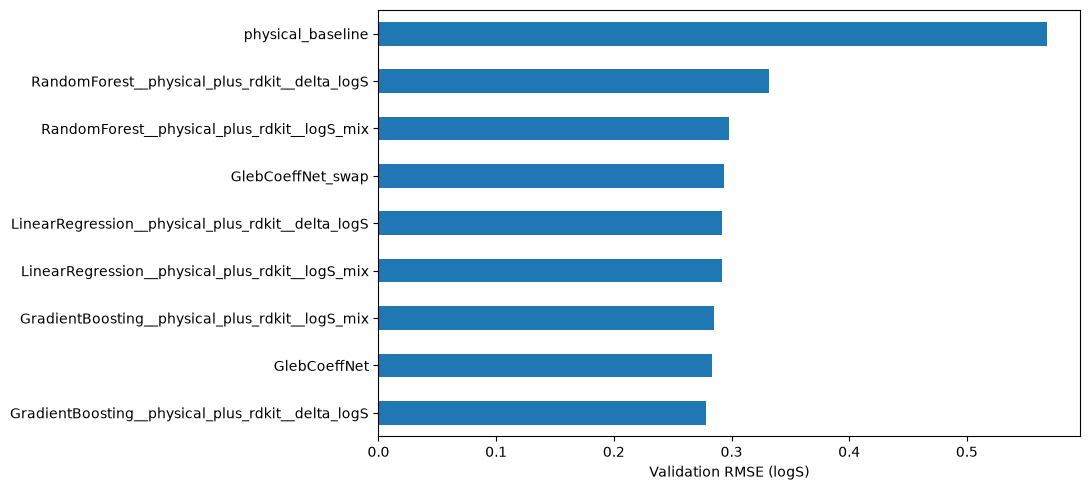

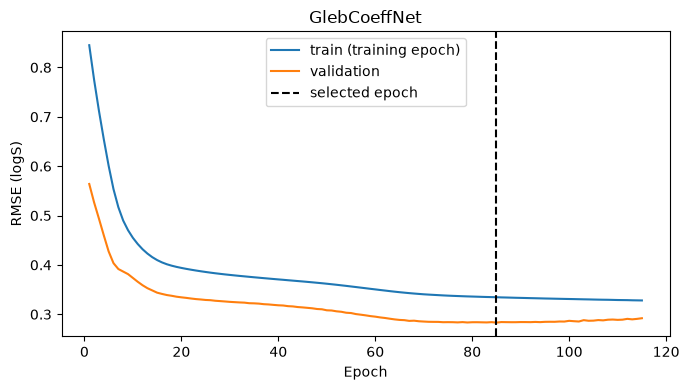

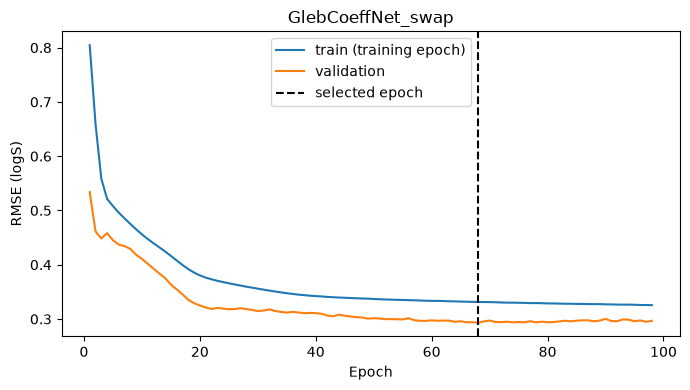

Симметрия:   0%|          | 0/9 [00:00<?, ?model/s]

,model_id,n,mean_abs_swap_error,max_abs_swap_error
0,physical_baseline,1000,0.000000,0.000000
1,LinearRegression__physical_plus_rdkit__logS_mix,1000,0.341243,1.585453
2,LinearRegression__physical_plus_rdkit__delta_logS,1000,0.341243,1.585453
3,RandomForest__physical_plus_rdkit__logS_mix,1000,0.252321,2.549926
4,RandomForest__physical_plus_rdkit__delta_logS,1000,0.245578,1.894481
5,GradientBoosting__physical_plus_rdkit__logS_mix,1000,0.227294,2.341762
6,GradientBoosting__physical_plus_rdkit__delta_logS,1000,0.228431,1.985756
7,GlebCoeffNet,1000,0.256755,2.099275
8,GlebCoeffNet_swap,1000,0.072031,0.657204


In [14]:
fig,ax = plt.subplots(figsize=(11,5))
validation_ranking.set_index("model_id")["RMSE_logS"].plot.barh(ax=ax)
ax.set(xlabel="Validation RMSE (logS)",ylabel=""); fig.tight_layout()
fig.savefig(OUT/"figures/validation_comparison.png",dpi=160); plt.show()
for model_id,bundle in TRAINED.items():
    if bundle["kind"] == "gleb":
        history = bundle["history"]
        fig,ax=plt.subplots(figsize=(7,4))
        ax.plot(history.epoch,history.train_RMSE,label="train (training epoch)")
        ax.plot(history.epoch,history.val_RMSE,label="validation")
        ax.axvline(bundle["best_epoch"],color="black",linestyle="--",label="selected epoch")
        ax.set(xlabel="Epoch",ylabel="RMSE (logS)",title=model_id); ax.legend();fig.tight_layout()
        fig.savefig(OUT/"figures"/f"{model_id}_history.png",dpi=160);plt.show()
if CFG["CHECK_SYMMETRY"]:
    subset = validation.sort_values(["experiment_id","x1"]).head(CFG["SYMMETRY_ROWS"])
    reverse = swap_solvents(subset)
    symmetry = []
    for model_id,bundle in tqdm(TRAINED.items(),desc="Симметрия",unit="model"):
        p = predict_logS(bundle,subset,progress=False)
        q = predict_logS(bundle,reverse,progress=False)
        symmetry.append({"model_id":model_id,"n":len(subset),"mean_abs_swap_error":float(np.mean(np.abs(p-q))),
                         "max_abs_swap_error":float(np.max(np.abs(p-q)))})
    symmetry = pd.DataFrame(symmetry)
    symmetry.to_csv(OUT/"metrics/symmetry_validation.csv",index=False)
    display(symmetry)

## 9. Манифест запуска и повторное использование

Все sklearn-модели сохраняются вместе с train-преобразованиями. Для сети сохранены
веса, преобразования, список Q-признаков и архитектура. Предсказание после загрузки
должно использовать ту же функцию `curve_value` и `predict_logS`.
Файлы joblib следует загружать только из доверенного собственного проекта.

In [15]:
def file_sha256(path):
    h=hashlib.sha256()
    with open(path,"rb") as stream:
        for chunk in iter(lambda:stream.read(1024*1024),b""):h.update(chunk)
    return h.hexdigest()

manifest = {"protocol":"training-comparison-1.0.0","created_at_utc":datetime.now(timezone.utc).isoformat(),
            "config":CFG,"feature_sets":FEATURE_SETS,"gleb_Q_features":Q_FEATURES,
            "input_files":[{"path":str(p.resolve()),"sha256":file_sha256(p)} for p in input_paths],
            "versions":{"python":platform.python_version(),"numpy":np.__version__,"pandas":pd.__version__,
                        "sklearn":sklearn.__version__,"torch":torch.__version__ if CFG["RUN_GLEB"] else None},
            "selection":selection,"model_ids":list(TRAINED)}
(OUT/"run_manifest.json").write_text(json.dumps(manifest,ensure_ascii=False,indent=2),encoding="utf-8")
print("Результаты:",OUT.resolve())
print("Основные таблицы: metrics/validation_ranking.csv, metrics/all_metrics.csv")
print("Выбор модели: selection_by_validation.json")

def load_bundle(model_id):
    folder=OUT/"models"/model_id
    bundle=json.loads((folder/"metadata.json").read_text(encoding="utf-8"))
    if bundle["kind"] == "tabular":
        bundle.update(joblib.load(folder/"model.joblib"))
    elif bundle["kind"] == "gleb":
        if not CFG["RUN_GLEB"]: raise RuntimeError("Для загрузки сети включите RUN_GLEB и выполните ячейку с PolyCoeffNet")
        model=PolyCoeffNet(len(bundle["features"]),bundle["degree"],bundle["hidden"])
        model.load_state_dict(torch.load(folder/"weights.pt",map_location="cpu",weights_only=True));model.eval()
        bundle.update(model=model,preprocessor=joblib.load(folder/"preprocessor.joblib"))
    return bundle

# Пример прогноза после загрузки (раскомментировать):
# restored = load_bundle(winner_id)
# predictions = predict_logS(restored, frames["val_unseen_solute"].head(10))

Результаты: /Users/georg/projects/Solubility/Article_code/training_v1
Основные таблицы: metrics/validation_ranking.csv, metrics/all_metrics.csv
Выбор модели: selection_by_validation.json
